<p style="background-color:#1B3A57;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:60px 20px;"><b>CNN - Brain Tumor Classification Project</b></p>

<div style="text-align: center;">
    <img src="https://www.researchgate.net/publication/357705499/figure/fig2/AS:1114613752045568@1642756035303/Simulation-images-of-brain-tumours-in-the-Kaggle-platform-36.png" width="700" height="400"/>
</div>

<h1 style="color: #1B3A57;">Introduction</h1>

<h1 id="import-libraries" style="color: #1B3A57;">Importing Libraries</h1>

In [6]:
import os
import cv2
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

<h1 id="load-dataset" style="color: #1B3A57;">Loading The Dataset</h1>

In [7]:
pwd

'/kaggle/working'

In [8]:
my_data= '/kaggle/input/brain-tumor-classification-mri'

In [9]:
os.listdir(my_data) 

['Training', 'Testing']

In [10]:
train_path = my_data+'/Training/'
test_path = my_data+'/Testing/'

In [11]:
os.listdir(train_path)

['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']

In [12]:
os.listdir(test_path)

['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']

In [13]:
class_names = os.listdir(train_path)
class_names

['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']

<h2 id="ld1" style="color: #5DADEC;">Sample Images</h2>

In [9]:
os.listdir(train_path+'glioma_tumor')[15]

'gg (449).jpg'

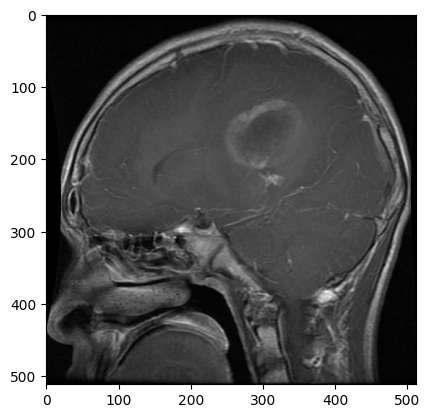

In [10]:
glioma_tumor_path = train_path+'glioma_tumor'+'/gg (112).jpg'
glioma_tumor_img = imread(glioma_tumor_path)
plt.imshow(glioma_tumor_img);

In [11]:
print(f"Shape of img: {glioma_tumor_img.shape}")

Shape of img: (512, 512, 3)


In [12]:
os.listdir(train_path+'meningioma_tumor')[20]

'm (35).jpg'

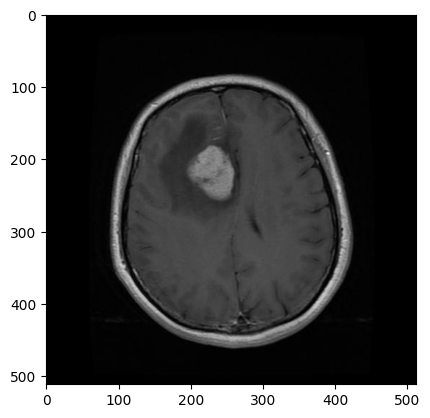

In [13]:
meningioma_tumor_path = train_path+'meningioma_tumor'+'/m (118).jpg'
meningioma_tumor_img = imread(meningioma_tumor_path)
plt.imshow(meningioma_tumor_img);

In [14]:
print(f"Shape of img: {meningioma_tumor_img.shape}")

Shape of img: (512, 512, 3)


In [15]:
os.listdir(train_path+'pituitary_tumor')[7]

'p (616).jpg'

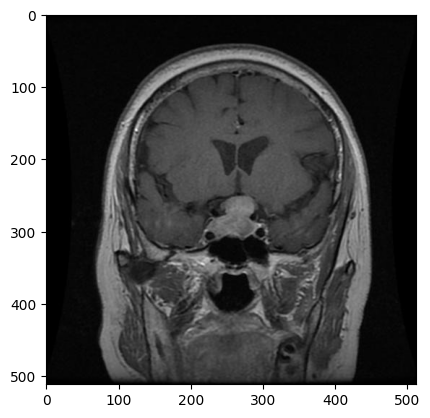

In [16]:
pituitary_tumor_path = train_path+'pituitary_tumor'+'/p (105).jpg'
pituitary_tumor_img = imread(pituitary_tumor_path)
plt.imshow(pituitary_tumor_img);

In [17]:
print(f"Shape of img: {pituitary_tumor_img.shape}")

Shape of img: (512, 512, 3)


In [18]:
os.listdir(train_path+'no_tumor')[10]

'image(29).jpg'

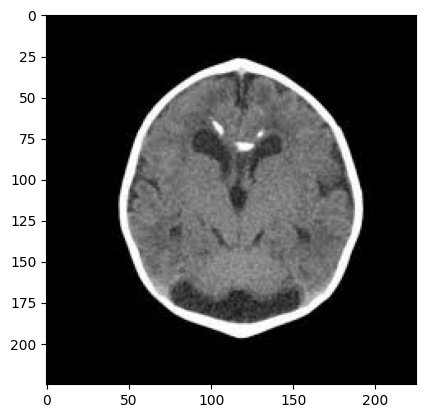

In [19]:
no_tumor_path = train_path+'no_tumor'+'/image (12).jpg'
no_tumor_img = imread(no_tumor_path)
plt.imshow(no_tumor_img);

In [20]:
print(f"Shape of img: {no_tumor_img.shape}")

Shape of img: (225, 225, 3)


In [21]:
# Determining common image shape train data

# Lists to store width and height values
x = []
y = []

# Processing images for each class
for class_name in class_names:
    class_path = os.path.join(train_path, class_name)
    for image_name in os.listdir(class_path):
        img = imread(os.path.join(class_path, image_name))
        if len(img.shape) == 3:   # Is it RGB?
            d1, d2, _ = img.shape
        else:     # Gray scale image
            d1, d2 = img.shape
        
        x.append(d1)
        y.append(d2)

# Calculating average width and height
mean_width = np.mean(x)
mean_height = np.mean(y)

print(f"Mean Width: {mean_width}")
print(f"Mean Height: {mean_height}")

Mean Width: 481.41637630662024
Mean Height: 480.1094076655052


In [22]:
# Determining common image shape test data

# Lists to store width and height values
x = []
y = []

# Processing images for each class
for class_name in class_names:
    class_path = os.path.join(test_path, class_name)
    for image_name in os.listdir(class_path):
        img = imread(os.path.join(class_path, image_name))
        if len(img.shape) == 3:   # Is it RGB?
            d1, d2, _ = img.shape
        else:     # Gray scale image
            d1, d2 = img.shape
        
        x.append(d1)
        y.append(d2)

# Calculating average width and height
mean_width = np.mean(x)
mean_height = np.mean(y)

print(f"Mean Width: {mean_width}")
print(f"Mean Height: {mean_height}")

Mean Width: 385.0253807106599
Mean Height: 372.48984771573606


**Explanation:**  

In this project, since the images in the dataset have varying sizes, it is necessary to resize all images to a consistent input shape. Based on the analysis, the average dimensions of the training set images were found to be **(481, 480)**, while those in the test set were **(385, 372)**.  

To ensure a more efficient training process and reduce computational cost, the **(224, 224, 3)** size was chosen. Additionally, as transfer learning will be used in later stages, this selection aims to maintain compatibility with pre-trained models.  

In [14]:
image_shape = (224, 224, 3)

<h1 id="data-pre" style="color: #1B3A57;">Data Preprocessing</h1>

In [24]:
print(glioma_tumor_img.max())
print(no_tumor_img.max())

253
255


You can see the max values ​​of some images above. These values ​​show that **the data was not scaled beforehand**. This stage was done for control purposes.

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [16]:
image_gen.flow_from_directory(train_path)

Found 2870 images belonging to 4 classes.


In [17]:
image_gen.flow_from_directory(test_path)

Found 394 images belonging to 4 classes.


<h1 id="modeling" style="color: #1B3A57;">Modeling</h1>

<h2 id="model1" style="color: #5DADEC;">CNN Modeling</h2>

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam

In [29]:
image_shape = (224, 224, 3)

In [25]:
batch_size = 64
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=(224, 224),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='categorical',
                                               shuffle=True,
                                               seed=42)

Found 2870 images belonging to 4 classes.


In [26]:
image_gen_test = ImageDataGenerator(rescale=1/255)

test_image_gen = image_gen_test.flow_from_directory(test_path,
                                                   target_size=(224, 224),  
                                                   color_mode='rgb',
                                                   batch_size=batch_size,
                                                   class_mode='categorical',
                                                   shuffle=False,
                                                   seed=42
                                                   )

Found 394 images belonging to 4 classes.


In [33]:
train_image_gen.class_indices

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

In [34]:
test_image_gen.class_indices

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

In [35]:
# `train_image_gen` ve `test_image_gen` ile doğrulama
for images, labels in train_image_gen:
    print(images.shape)  # (batch_size, image_height, image_width, 3)
    print(labels.shape)   # (batch_size, 4) --> One-hot encoded etiketler
    break

(64, 224, 224, 3)
(64, 4)


In [36]:
model = Sequential()

model.add(Input(shape=image_shape))

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(train_image_gen.class_indices), activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',patience=10)

In [39]:
results = model.fit(train_image_gen,epochs=50,
                    validation_data=test_image_gen,
                    callbacks=[early_stop])

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 57s 915ms/step - accuracy: 0.3415 - loss: 1.3638 - precision: 0.2795 - recall: 0.0187 - val_accuracy: 0.2208 - val_loss: 1.5737 - val_precision: 0.0263 - val_recall: 0.0051
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 681ms/step - accuracy: 0.3808 - loss: 1.3075 - precision: 0.3106 - recall: 0.0237 - val_accuracy: 0.2030 - val_loss: 1.5826 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 678ms/step - accuracy: 0.4448 - loss: 1.2303 - precision: 0.3812 - recall: 0.0426 - val_accuracy: 0.2360 - val_loss: 1.6411 - val_precision: 0.2593 - val_recall: 0.0178
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 683ms/step - accuracy: 0.4755 - loss: 1.1806 - precision: 0.5245 - recall: 0.1099 - val_accuracy: 0.2640 - val_loss: 1.6835 - val_precision: 0.1916 - val_recall: 0.0812
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 685ms/step - accuracy: 0.5056 - loss: 1.1249 - precision: 0.5711 - recall: 0.2041 - val_accuracy: 0.2411 - val_loss: 

In [44]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
0,0.362718,1.339380,0.262626,0.009059,0.220812,1.573664,0.026316,0.005076
1,0.388502,1.293650,0.301775,0.017770,0.203046,1.582555,0.000000,0.000000
2,0.454355,1.213419,0.475877,0.075610,0.236041,1.641053,0.259259,0.017766
3,0.478746,1.170139,0.563863,0.126132,0.263959,1.683458,0.191617,0.081218
4,0.506969,1.112270,0.587793,0.218118,0.241117,1.749735,0.230769,0.121827


In [41]:
# Metrics for CNN
cnn_train_accuracy = results.history['accuracy']
cnn_val_accuracy = results.history['val_accuracy']
cnn_train_loss = results.history['loss']
cnn_val_loss = results.history['val_loss']

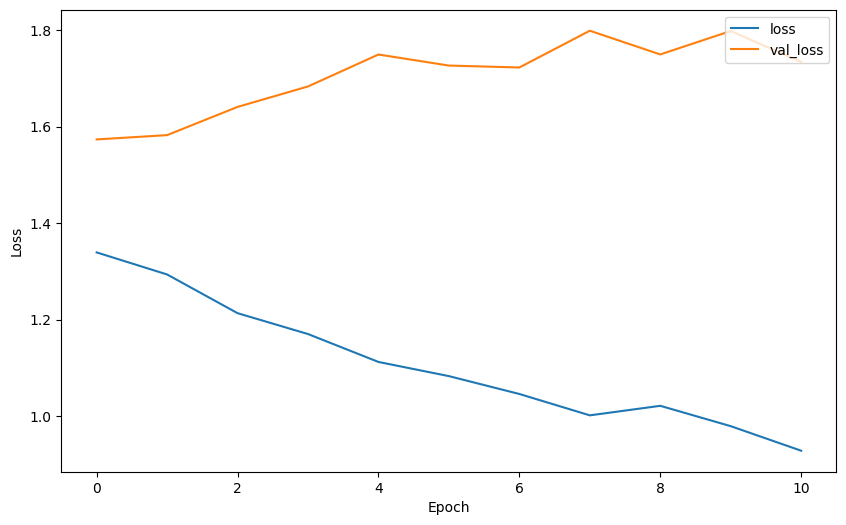

In [42]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

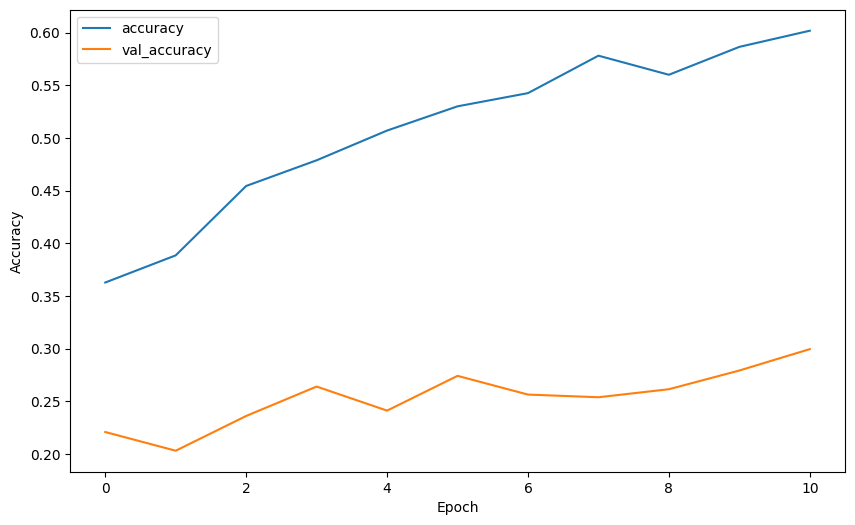

In [43]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

As you can see above, the scores of the model is not that good. So let's try some **transfer learning models** too.

<h2 id="model2" style="color: #5DADEC;">Transfer Learning - VGG16</h2>

In [45]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Adding customized layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(len(train_image_gen.class_indices), activation='softmax')(x)

# New model
vgg_model = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [46]:
vgg_model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 17,926,596 (68.38 MB)

 Trainable params: 3,211,908 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [47]:
vgg_results = vgg_model.fit(
    train_image_gen,
    epochs=50,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.2991 - loss: 2.2503 - val_accuracy: 0.3020 - val_loss: 1.3440
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 737ms/step - accuracy: 0.3808 - loss: 1.2563 - val_accuracy: 0.2944 - val_loss: 1.3523
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 736ms/step - accuracy: 0.4002 - loss: 1.2168 - val_accuracy: 0.2563 - val_loss: 1.4059
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 38s 727ms/step - accuracy: 0.4161 - loss: 1.1727 - val_accuracy: 0.2970 - val_loss: 1.2990
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 736ms/step - accuracy: 0.4319 - loss: 1.1500 - val_accuracy: 0.2995 - val_loss: 1.3696
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 38s 730ms/step - accuracy: 0.4387 - loss: 1.1361 - val_accuracy: 0.3046 - val_loss: 1.2828
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 38s 727ms/step - accuracy: 0.4076 - loss: 1.1492 - val_accuracy: 0.3299 - val_loss: 1.2637
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 745ms/step - accuracy: 0.4183 - loss: 1.1452 - val_accurac

In [48]:
summary = pd.DataFrame(vgg_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.316376,1.660463,0.302030,1.343953
1,0.385366,1.242252,0.294416,1.352280
2,0.403484,1.206726,0.256345,1.405859
3,0.412544,1.172557,0.296954,1.298954
4,0.444948,1.134913,0.299492,1.369562


In [49]:
# Metrics for VGG16
vgg16_train_accuracy = vgg_results.history['accuracy']
vgg16_val_accuracy = vgg_results.history['val_accuracy']
vgg16_train_loss = vgg_results.history['loss']
vgg16_val_loss = vgg_results.history['val_loss']

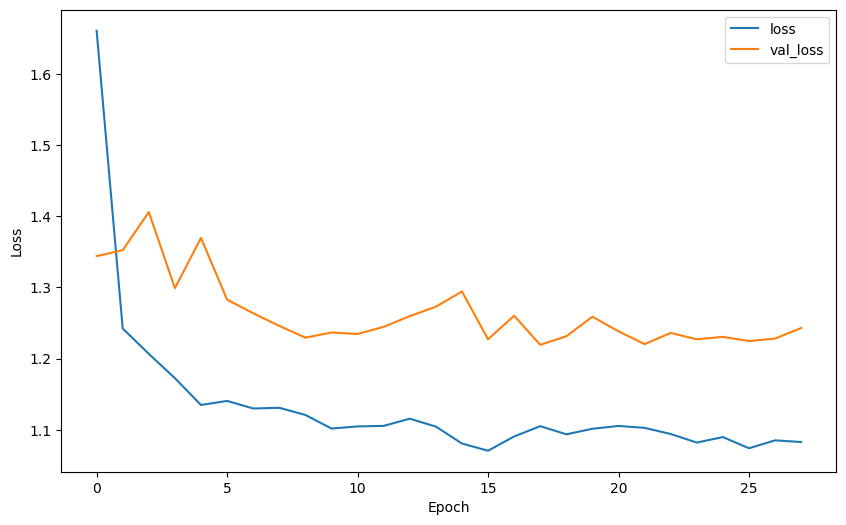

In [50]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

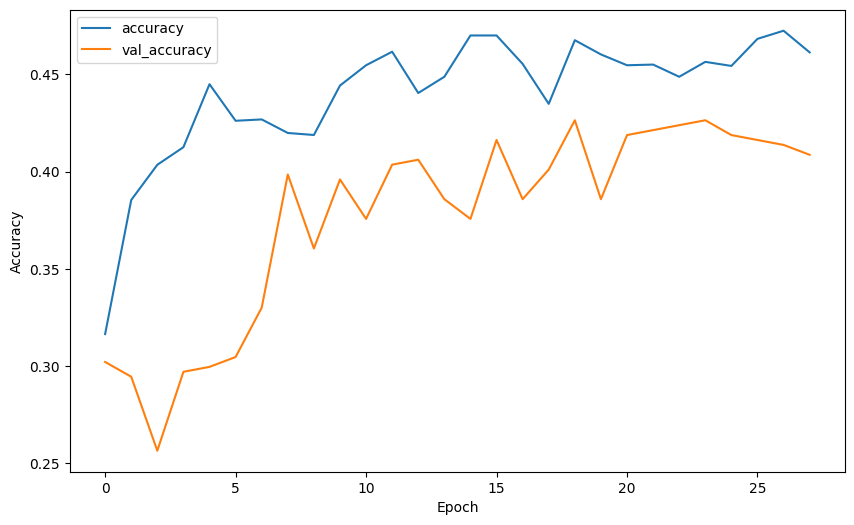

In [51]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

<h2 id="model3" style="color: #5DADEC;">Transfer Learning - ResNet50</h2>

In [52]:
from tensorflow.keras.applications import ResNet50

# Loading ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Adding customized layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(len(train_image_gen.class_indices), activation='softmax')(x)

# New model
resnet_model = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [53]:
resnet_model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 36,433,412 (138.98 MB)

 Trainable params: 12,845,700 (49.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [54]:
resnet_results = resnet_model.fit(
    train_image_gen,
    epochs=50,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 61s 945ms/step - accuracy: 0.2648 - loss: 5.1826 - val_accuracy: 0.2538 - val_loss: 1.6212
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 695ms/step - accuracy: 0.2897 - loss: 1.4773 - val_accuracy: 0.2944 - val_loss: 1.3878
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 698ms/step - accuracy: 0.2901 - loss: 1.4298 - val_accuracy: 0.2944 - val_loss: 1.3893
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 692ms/step - accuracy: 0.2766 - loss: 1.3740 - val_accuracy: 0.2893 - val_loss: 1.3913
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 694ms/step - accuracy: 0.2849 - loss: 1.3718 - val_accuracy: 0.2817 - val_loss: 1.3897
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 698ms/step - accuracy: 0.2833 - loss: 1.3666 - val_accuracy: 0.2893 - val_loss: 1.3962
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 689ms/step - accuracy: 0.2906 - loss: 1.3617 - val_accuracy: 0.2893 - val_loss: 1.3987
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 690ms/step - accuracy: 0.2993 - loss: 1.3614 - val_accu

In [55]:
summary = pd.DataFrame(resnet_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.280139,2.842179,0.253807,1.621158
1,0.283972,1.423473,0.294416,1.387761
2,0.284321,1.410706,0.294416,1.389345
3,0.286411,1.372182,0.289340,1.391274
4,0.284321,1.390223,0.281726,1.389664


In [56]:
# Metrics for ResNet50
resnet_train_accuracy = resnet_results.history['accuracy']
resnet_val_accuracy = resnet_results.history['val_accuracy']
resnet_train_loss = resnet_results.history['loss']
resnet_val_loss = resnet_results.history['val_loss']

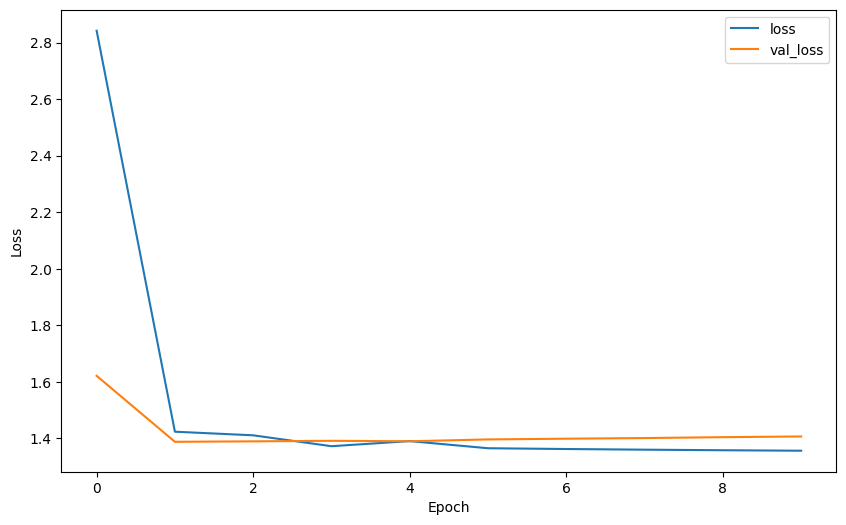

In [57]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

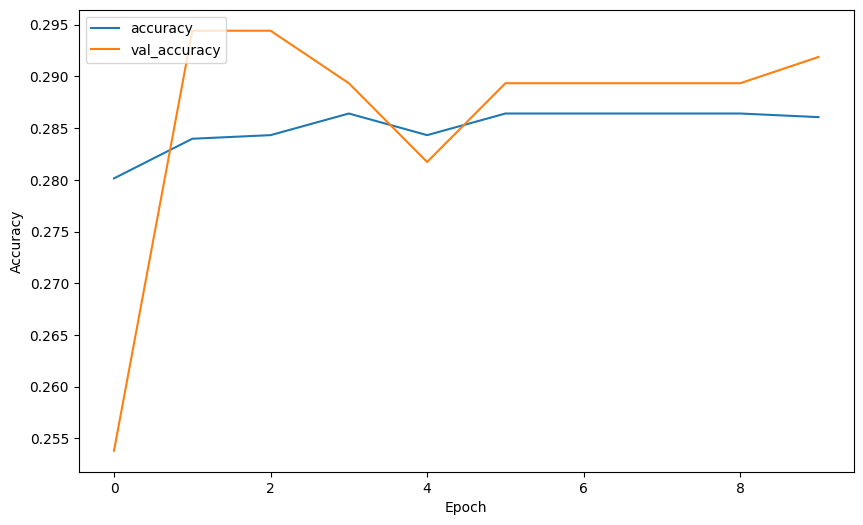

In [58]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

<h2 id="model4" style="color: #5DADEC;">Transfer Learning - InceptionV3</h2>

In [59]:
from tensorflow.keras.applications import InceptionV3

# Loading InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Adding customized layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(len(train_image_gen.class_indices), activation='softmax')(x)

# New model
inception_model = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

inception_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [60]:
inception_model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 111, 111, 32)   │            864 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 111, 111, 32)   │             96 │ conv2d_6[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 111, 111, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 109, 109, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 109, 109, 32)   │             96 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 109, 109, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 109, 109, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 109, 109, 64)   │            192 │ conv2d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 109, 109, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 54, 54, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 54, 54, 80)     │          5,120 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 54, 54, 80)     │            240 │ conv2d_9[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 54, 54, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 52, 52, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 52, 52, 192)    │            576 │ conv2d_10[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 28,357,028 (108.17 MB)

 Trainable params: 6,554,244 (25.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [61]:
inception_results = inception_model.fit(
    train_image_gen,
    epochs=50,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.3816 - loss: 10.7967 - val_accuracy: 0.3046 - val_loss: 1.3716
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 682ms/step - accuracy: 0.4816 - loss: 1.1060 - val_accuracy: 0.3629 - val_loss: 1.3153
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 687ms/step - accuracy: 0.5306 - loss: 1.0207 - val_accuracy: 0.3934 - val_loss: 1.2861
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 687ms/step - accuracy: 0.5521 - loss: 1.0070 - val_accuracy: 0.4036 - val_loss: 1.3005
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 675ms/step - accuracy: 0.5289 - loss: 1.0027 - val_accuracy: 0.3934 - val_loss: 1.2785
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 695ms/step - accuracy: 0.5657 - loss: 0.9538 - val_accuracy: 0.3553 - val_loss: 1.2350
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 686ms/step - accuracy: 0.5683 - loss: 0.9385 - val_accuracy: 0.3756 - val_loss: 1.2512
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 685ms/step - accuracy: 0.5839 - loss: 0.9101 - val_accura

In [62]:
summary = pd.DataFrame(inception_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.433798,5.175171,0.304569,1.371580
1,0.502091,1.072643,0.362944,1.315265
2,0.530662,1.009656,0.393401,1.286141
3,0.546341,1.005180,0.403553,1.300503
4,0.531707,1.000459,0.393401,1.278512


In [63]:
# Metrics for InceptionV3
inception_train_accuracy = inception_results.history['accuracy']
inception_val_accuracy = inception_results.history['val_accuracy']
inception_train_loss = inception_results.history['loss']
inception_val_loss = inception_results.history['val_loss']

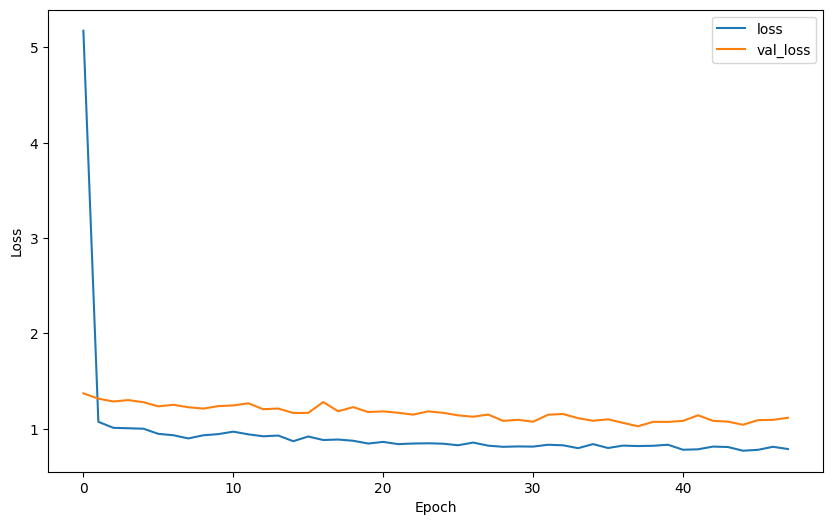

In [64]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

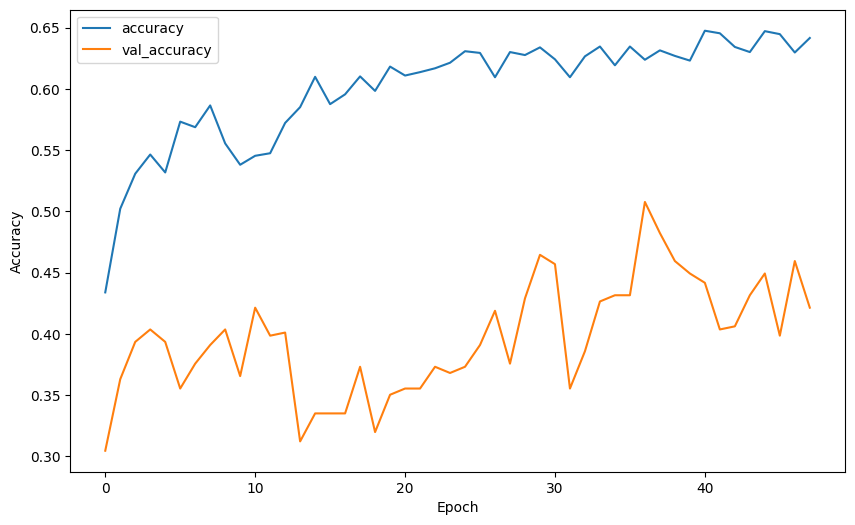

In [65]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

<h2 id="model5" style="color: #5DADEC;">Transfer Learning - MobileNetV2</h2>

In [66]:
from tensorflow.keras.applications import MobileNetV2

# Loading MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Adding customized layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(len(train_image_gen.class_indices), activation='softmax')(x)

# New model
mobilenet_model = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [67]:
mobilenet_model.summary()

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 10,286,788 (39.24 MB)

 Trainable params: 8,028,804 (30.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [68]:
mobilenet_results = mobilenet_model.fit(
    train_image_gen,
    epochs=50,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 59s 925ms/step - accuracy: 0.4637 - loss: 4.3149 - val_accuracy: 0.4898 - val_loss: 1.2379
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 664ms/step - accuracy: 0.5533 - loss: 0.9803 - val_accuracy: 0.4365 - val_loss: 1.2921
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 675ms/step - accuracy: 0.6535 - loss: 0.8063 - val_accuracy: 0.5584 - val_loss: 1.3635
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 670ms/step - accuracy: 0.6824 - loss: 0.7426 - val_accuracy: 0.5203 - val_loss: 1.2696
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 669ms/step - accuracy: 0.7391 - loss: 0.6642 - val_accuracy: 0.5584 - val_loss: 1.7377
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 667ms/step - accuracy: 0.7345 - loss: 0.6845 - val_accuracy: 0.6142 - val_loss: 1.4355
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 668ms/step - accuracy: 0.7529 - loss: 0.6139 - val_accuracy: 0.5685 - val_loss: 1.4872
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 668ms/step - accuracy: 0.7601 - loss: 0.6151 - val_accu

In [69]:
summary = pd.DataFrame(mobilenet_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.496516,2.342186,0.489848,1.237877
1,0.593031,0.933485,0.436548,1.292110
2,0.663066,0.799788,0.558376,1.363473
3,0.691986,0.721154,0.520305,1.269633
4,0.735888,0.691420,0.558376,1.737699


In [70]:
# Metrics for MobileNetV2
mobilenet_train_accuracy = mobilenet_results.history['accuracy']
mobilenet_val_accuracy = mobilenet_results.history['val_accuracy']
mobilenet_train_loss = mobilenet_results.history['loss']
mobilenet_val_loss = mobilenet_results.history['val_loss']

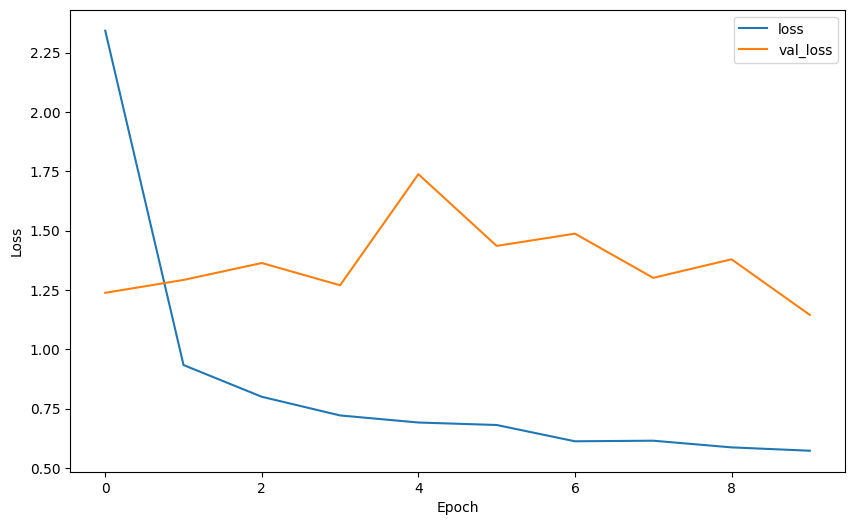

In [71]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

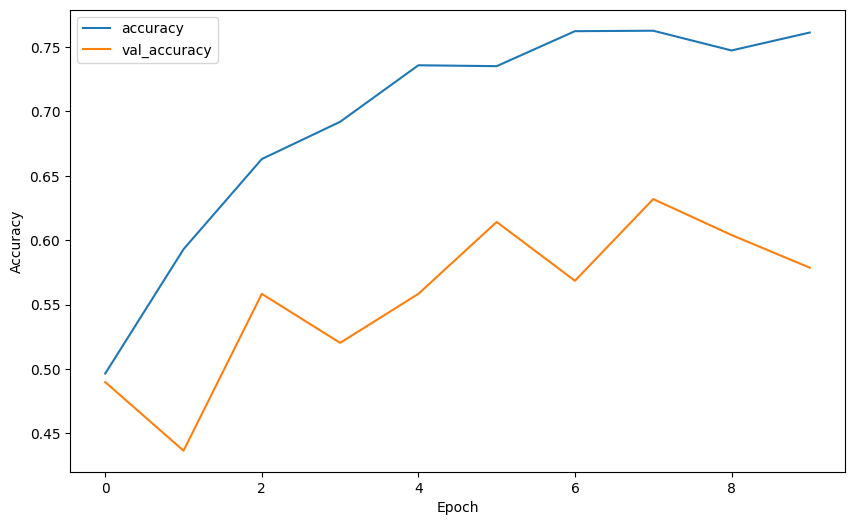

In [72]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

<h2 id="model6" style="color: #5DADEC;">Transfer Learning - DenseNet121</h2>

In [73]:
from tensorflow.keras.applications import DenseNet121

# Loading DenseNet121 model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Adding customized layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(len(train_image_gen.class_indices), activation='softmax')(x)

# New model
dense_model = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

dense_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [74]:
dense_model.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer_6[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 13,460,676 (51.35 MB)

 Trainable params: 6,423,172 (24.50 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [75]:
dense_results = dense_model.fit(
    train_image_gen,
    epochs=50,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.3226 - loss: 10.6768 - val_accuracy: 0.2030 - val_loss: 1.3788
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 680ms/step - accuracy: 0.4053 - loss: 1.2519 - val_accuracy: 0.2589 - val_loss: 1.3714
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 697ms/step - accuracy: 0.4273 - loss: 1.2270 - val_accuracy: 0.2513 - val_loss: 1.3141
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 694ms/step - accuracy: 0.4249 - loss: 1.1935 - val_accuracy: 0.2538 - val_loss: 1.3898
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 679ms/step - accuracy: 0.4661 - loss: 1.1739 - val_accuracy: 0.2843 - val_loss: 1.3014
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 689ms/step - accuracy: 0.4757 - loss: 1.1383 - val_accuracy: 0.2183 - val_loss: 1.3121
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 683ms/step - accuracy: 0.4671 - loss: 1.1269 - val_accuracy: 0.2259 - val_loss: 1.3892
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 682ms/step - accuracy: 0.4643 - loss: 1.1189 - val_accura

In [76]:
summary = pd.DataFrame(dense_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.347735,4.881215,0.203046,1.378827
1,0.401045,1.251777,0.258883,1.371372
2,0.412544,1.229395,0.251269,1.314124
3,0.445296,1.185650,0.253807,1.389785
4,0.473171,1.162901,0.284264,1.301417


In [77]:
# Metrics for DenseNet121
densenet_train_accuracy = dense_results.history['accuracy']
densenet_val_accuracy = dense_results.history['val_accuracy']
densenet_train_loss = dense_results.history['loss']
densenet_val_loss = dense_results.history['val_loss']

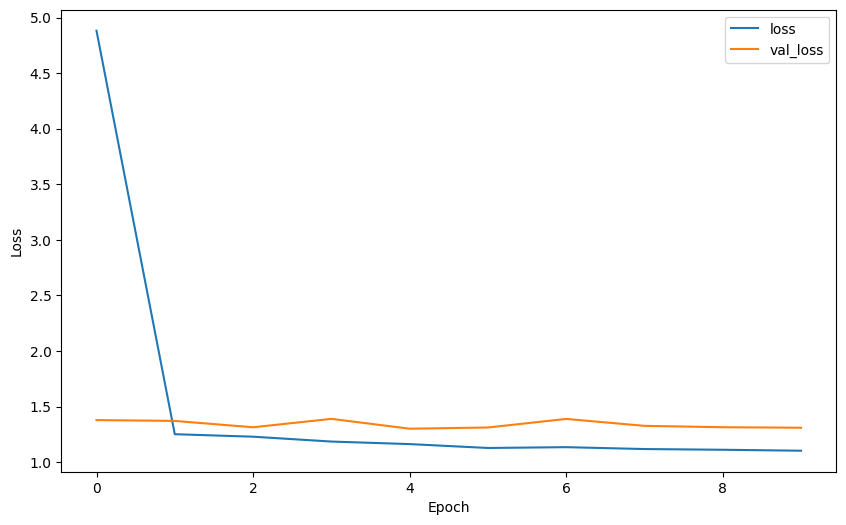

In [78]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

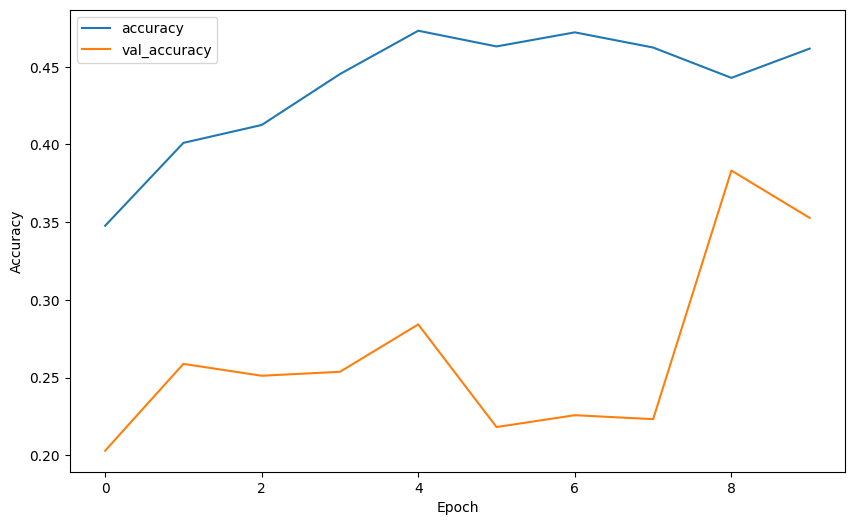

In [79]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

<h2 id="model7" style="color: #5DADEC;">Transfer Learning - Xception</h2>

In [80]:
from tensorflow.keras.applications import Xception

# Loading Xception model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Adding customized layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(len(train_image_gen.class_indices), activation='softmax')(x)

# New model
xception_model = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

xception_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [81]:
xception_model.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 111, 111, 32)   │            864 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_bn           │ (None, 111, 111, 32)   │            128 │ block1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_act          │ (None, 111, 111, 32)   │              0 │ block1_conv1_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 109, 109, 64)   │         18,432 │ block1_conv1_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_bn           │ (None, 109, 109, 64)   │            256 │ block1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_act          │ (None, 109, 109, 64)   │              0 │ block1_conv2_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1           │ (None, 109, 109, 128)  │          8,768 │ block1_conv2_act[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_act       │ (None, 109, 109, 128)  │              0 │ block2_sepconv1_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2           │ (None, 109, 109, 128)  │         17,536 │ block2_sepconv2_act[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_100 (Conv2D)       │ (None, 55, 55, 128)    │          8,192 │ block1_conv2_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 55, 55, 128)    │              0 │ block2_sepconv2_bn[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 33,707,180 (128.58 MB)

 Trainable params: 12,845,700 (49.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [82]:
xception_results = xception_model.fit(
    train_image_gen,
    epochs=50,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.4199 - loss: 8.2598 - val_accuracy: 0.5305 - val_loss: 1.1792
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 736ms/step - accuracy: 0.5899 - loss: 1.0422 - val_accuracy: 0.5533 - val_loss: 1.3557
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 737ms/step - accuracy: 0.6440 - loss: 0.9125 - val_accuracy: 0.5381 - val_loss: 1.2324
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 736ms/step - accuracy: 0.6413 - loss: 0.8308 - val_accuracy: 0.5431 - val_loss: 1.6601
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 38s 727ms/step - accuracy: 0.6728 - loss: 0.7985 - val_accuracy: 0.5533 - val_loss: 1.2336
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 742ms/step - accuracy: 0.6762 - loss: 0.7766 - val_accuracy: 0.6041 - val_loss: 1.6288
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 746ms/step - accuracy: 0.6788 - loss: 0.7880 - val_accuracy: 0.4797 - val_loss: 1.8490
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 743ms/step - accuracy: 0.6649 - loss: 0.8105 - val_accurac

In [83]:
summary = pd.DataFrame(xception_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.483275,3.918182,0.530457,1.179214
1,0.604878,0.988204,0.553299,1.355740
2,0.637282,0.904999,0.538071,1.232411
3,0.638328,0.849509,0.543147,1.660079
4,0.656446,0.801148,0.553299,1.233562


In [84]:
# Metrics for Xception
xception_train_accuracy = xception_results.history['accuracy']
xception_val_accuracy = xception_results.history['val_accuracy']
xception_train_loss = xception_results.history['loss']
xception_val_loss = xception_results.history['val_loss']

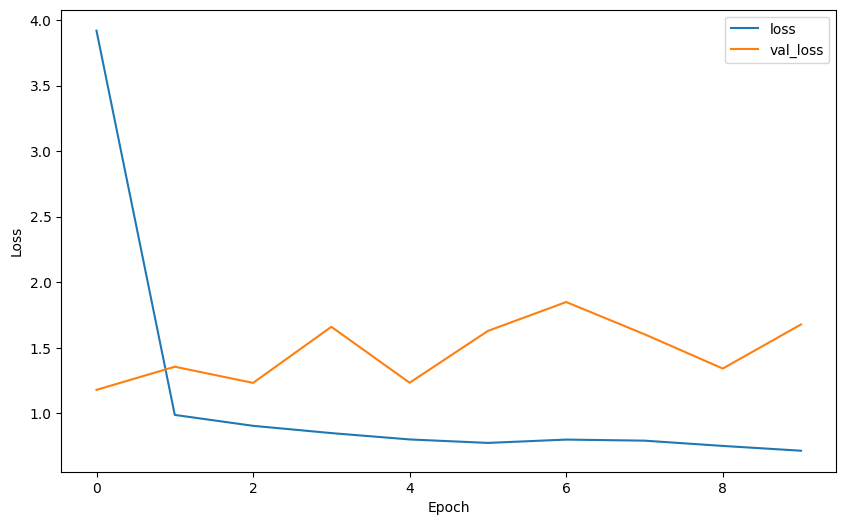

In [85]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

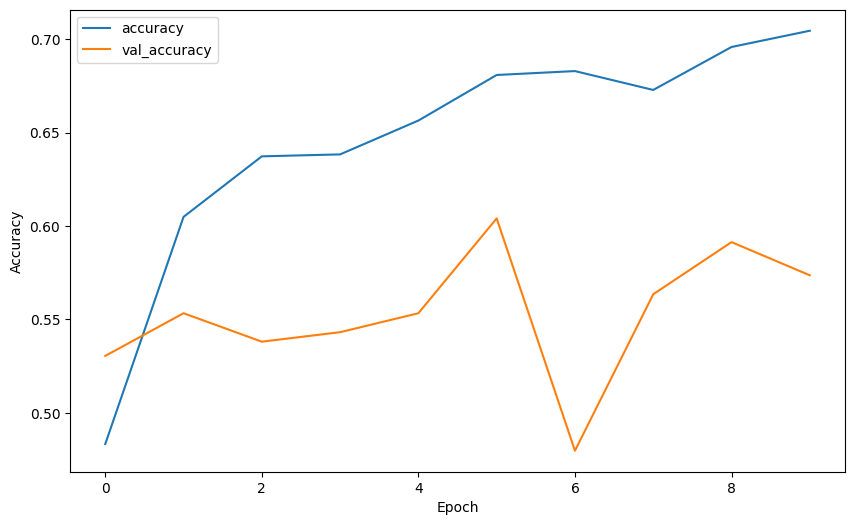

In [86]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

<h2 id="model4" style="color: #5DADEC;">Transfer Learning - EfficientNetB0</h2>

In [87]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D

# Loading EfficientNetB0 Model
efficient_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=image_shape))
efficient_model.trainable = False

# Adding customized layers
x = efficient_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# New model
efficient_model = Model(inputs=efficient_model.input, outputs=predictions)

efficient_model.compile(optimizer=Adam(learning_rate=0.0001),
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [88]:
efficient_model.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [89]:
efficient_results = efficient_model.fit(
    train_image_gen,
    epochs=50,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.2730 - loss: 1.3752 - val_accuracy: 0.1878 - val_loss: 1.4162
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 668ms/step - accuracy: 0.2799 - loss: 1.3560 - val_accuracy: 0.1878 - val_loss: 1.4314
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 673ms/step - accuracy: 0.2762 - loss: 1.3520 - val_accuracy: 0.1878 - val_loss: 1.4328
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 670ms/step - accuracy: 0.2957 - loss: 1.3484 - val_accuracy: 0.2538 - val_loss: 1.4313
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 671ms/step - accuracy: 0.2811 - loss: 1.3564 - val_accuracy: 0.2919 - val_loss: 1.4330
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 671ms/step - accuracy: 0.2864 - loss: 1.3562 - val_accuracy: 0.2919 - val_loss: 1.4336
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 659ms/step - accuracy: 0.2733 - loss: 1.3596 - val_accuracy: 0.1878 - val_loss: 1.4346
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 682ms/step - accuracy: 0.3016 - loss: 1.3462 - val_accurac

In [90]:
summary = pd.DataFrame(efficient_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.282230,1.366439,0.187817,1.416208
1,0.284321,1.352106,0.187817,1.431447
2,0.284669,1.354378,0.187817,1.432831
3,0.280488,1.351389,0.253807,1.431347
4,0.288502,1.352372,0.291878,1.432984


In [91]:
# Metrics for EfficientNet
efficient_train_accuracy = efficient_results.history['accuracy']
efficient_val_accuracy = efficient_results.history['val_accuracy']
efficient_train_loss = efficient_results.history['loss']
efficient_val_loss = efficient_results.history['val_loss']

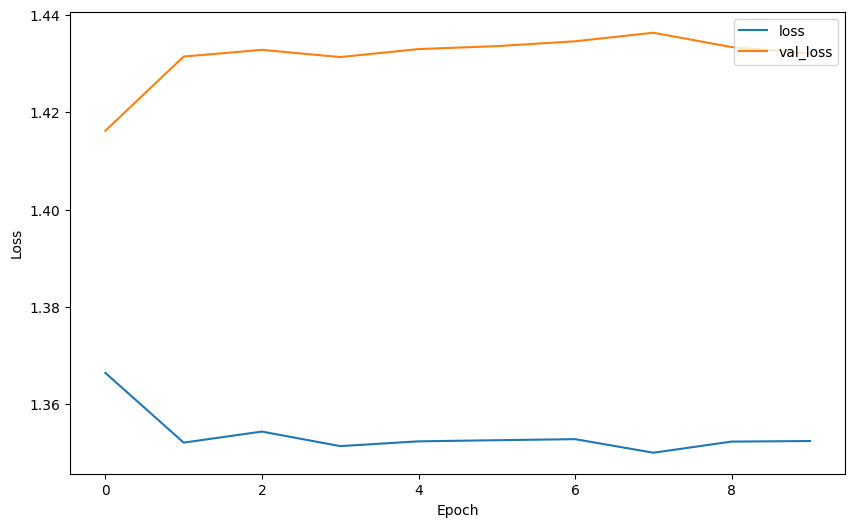

In [92]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

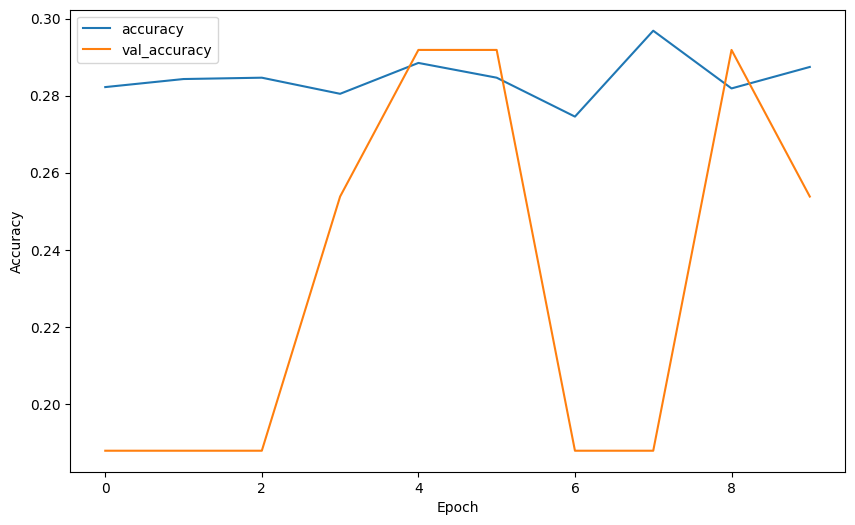

In [93]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

<h1 id="compare-models" style="color: #1B3A57;">Comparing Models</h1>

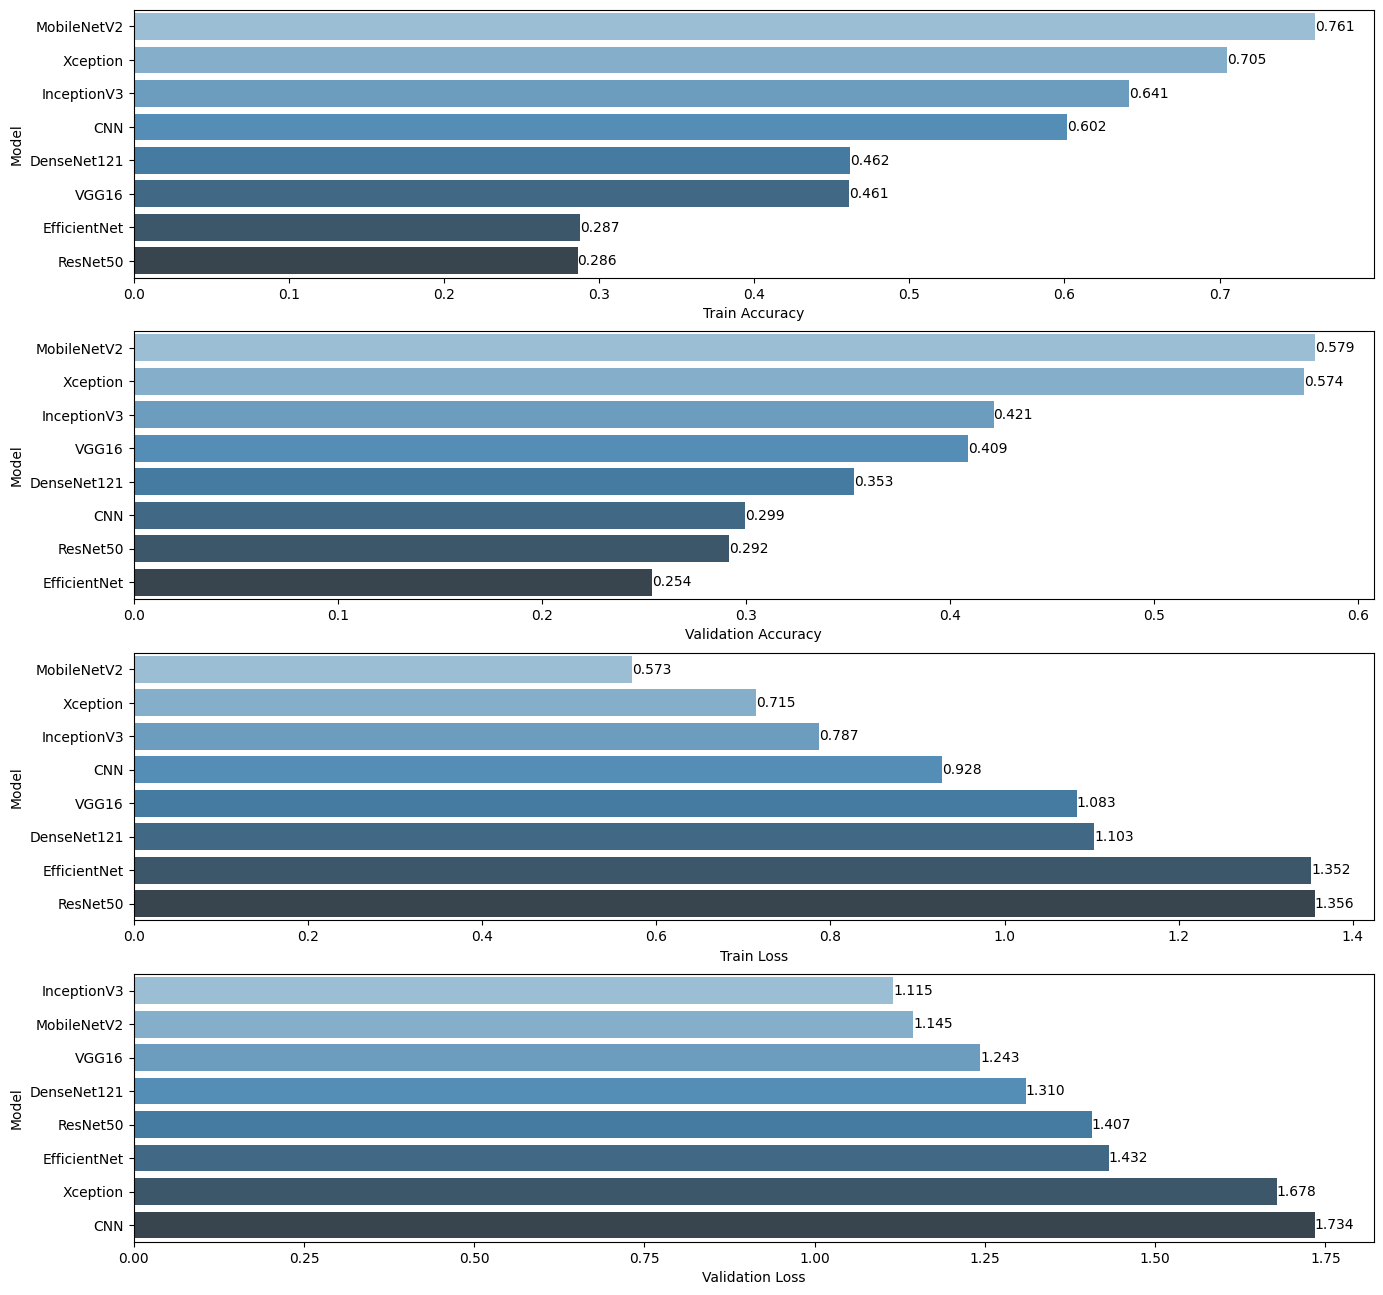

In [95]:
compare = pd.DataFrame({
    "Model": ["CNN", "VGG16", "ResNet50", "InceptionV3", "MobileNetV2", "DenseNet121", "Xception", "EfficientNet"],
    "Train Accuracy": [cnn_train_accuracy[-1], vgg16_train_accuracy[-1], resnet_train_accuracy[-1], inception_train_accuracy[-1], mobilenet_train_accuracy[-1] , densenet_train_accuracy[-1], xception_train_accuracy[-1], efficient_train_accuracy[-1]],
    "Validation Accuracy": [cnn_val_accuracy[-1], vgg16_val_accuracy[-1], resnet_val_accuracy[-1], inception_val_accuracy[-1], mobilenet_val_accuracy[-1] , densenet_val_accuracy[-1], xception_val_accuracy[-1], efficient_val_accuracy[-1]],
    "Train Loss": [cnn_train_loss[-1], vgg16_train_loss[-1], resnet_train_loss[-1], inception_train_loss[-1], mobilenet_train_loss[-1], densenet_train_loss[-1], xception_train_loss[-1], efficient_train_loss[-1]],
    "Validation Loss": [cnn_val_loss[-1], vgg16_val_loss[-1], resnet_val_loss[-1], inception_val_loss[-1], mobilenet_val_loss[-1], densenet_val_loss[-1], xception_val_loss[-1], efficient_val_loss[-1]]
})

def labels(ax):
    for p in ax.patches:
        width = p.get_width()                        # get bar length
        ax.text(width,                               # set the text at 1 unit right of the bar
                p.get_y() + p.get_height() / 2,      # get Y coordinate + X coordinate / 2
                '{:1.3f}'.format(width),             # set variable to display, 2 decimals
                ha = 'left',                         # horizontal alignment
                va = 'center')                       # vertical alignment
    
plt.figure(figsize=(16,16))

plt.subplot(411)
compare = compare.sort_values(by="Train Accuracy", ascending=False)
ax=sns.barplot(x="Train Accuracy", y="Model", data=compare, palette="Blues_d")
labels(ax)

plt.subplot(412)
compare = compare.sort_values(by="Validation Accuracy", ascending=False)
ax=sns.barplot(x="Validation Accuracy", y="Model", data=compare, palette="Blues_d")
labels(ax)

plt.subplot(413)
compare = compare.sort_values(by="Train Loss", ascending=True)
ax=sns.barplot(x="Train Loss", y="Model", data=compare, palette="Blues_d")
labels(ax)

plt.subplot(414)
compare = compare.sort_values(by="Validation Loss", ascending=True)
ax=sns.barplot(x="Validation Loss", y="Model", data=compare, palette="Blues_d")
labels(ax)

plt.show()

Looking at the graph above, the **MobileNet model has been selected for the final model** and this model will be worked on to get better scores and eleminate overfitting.

<h1 id="model4" style="color: #1B3A57;">Developing The Model</h1>

In [103]:
# First try
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation process
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_image_gen = train_datagen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=64, class_mode='categorical'
)

test_image_gen = test_datagen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=64, class_mode='categorical'
)

# Load MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add new layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer='l2')(x)
x = Dropout(0.5)(x)
x = Dense(len(train_image_gen.class_indices), activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=x)

# Freeze the pre-trained layers initially
for layer in base_model.layers:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1)

# Initial training (with frozen base model)
history = mobilenet_model.fit(
    train_image_gen,
    epochs=10,
    validation_data=test_image_gen,
    callbacks=[early_stop, reduce_lr]
)

# Unfreeze some layers for fine-tuning
for layer in base_model.layers[-20:]:  # Unfreeze the last 20 layers
    layer.trainable = True

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 831ms/step - accuracy: 0.5169 - loss: 4.8817 - val_accuracy: 0.5279 - val_loss: 3.5526 - learning_rate: 0.0010
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 671ms/step - accuracy: 0.7648 - loss: 2.4320 - val_accuracy: 0.5102 - val_loss: 2.5713 - learning_rate: 0.0010
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 663ms/step - accuracy: 0.7890 - loss: 1.6464 - val_accuracy: 0.5457 - val_loss: 2.2054 - learning_rate: 0.0010
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 670ms/step - accuracy: 0.7953 - loss: 1.2906 - val_accuracy: 0.5787 - val_loss: 1.9337 - learning_rate: 0.0010
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 672ms/step - accuracy: 0.8222 - loss: 1.0524 - val_accuracy: 0.6091 - val_loss: 1.6878 - learning_rate: 0.0010
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 654ms/step - accuracy: 0.8360 - loss: 0.9036 - val_accuracy: 0.6294 - val_loss: 1.5273 - learning_rate: 0.0010
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 665ms/step - accuracy: 0.8377 - loss: 0.8120 - val_

In [104]:
# Fine-tuning training
mobilenetV2_results = mobilenet_model.fit(
    train_image_gen,
    epochs=20,
    validation_data=test_image_gen,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 56s 850ms/step - accuracy: 0.6283 - loss: 1.3073 - val_accuracy: 0.6574 - val_loss: 1.4821 - learning_rate: 1.0000e-05
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 669ms/step - accuracy: 0.7918 - loss: 0.9416 - val_accuracy: 0.6472 - val_loss: 1.5121 - learning_rate: 1.0000e-05
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.8254 - loss: 0.8561
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 664ms/step - accuracy: 0.8253 - loss: 0.8562 - val_accuracy: 0.6447 - val_loss: 1.5288 - learning_rate: 1.0000e-05
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 667ms/step - accuracy: 0.8387 - loss: 0.8277 - val_accuracy: 0.6548 - val_loss: 1.5292 - learning_rate: 3.0000e-06
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.8248 - loss: 0.8304
Epoch 5: ReduceLROnPlateau reducing learning rate to 1e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 663ms/step - accuracy: 0.8250 - loss: 0.830

In [106]:
# Metrics for MobileNetV2
mobilenetV2_train_accuracy = mobilenet_results.history['accuracy']
mobilenetV2_val_accuracy = mobilenet_results.history['val_accuracy']
mobilenetV2_train_loss = mobilenet_results.history['loss']
mobilenetV2_val_loss = mobilenet_results.history['val_loss']

In [107]:
# Second try
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation improvements
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_image_gen = train_datagen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=64, class_mode='categorical'
)

test_image_gen = test_datagen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=64, class_mode='categorical'
)

# Load MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add new layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_regularizer='l2')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu', kernel_regularizer='l2')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(len(train_image_gen.class_indices), activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=x)

# Freeze initial layers
for layer in base_model.layers:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)

# First training phase
history = mobilenet_model.fit(
    train_image_gen,
    epochs=15,
    validation_data=test_image_gen,
    callbacks=[early_stop, reduce_lr]
)

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.
Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 56s 907ms/step - accuracy: 0.5328 - loss: 11.4861 - val_accuracy: 0.4467 - val_loss: 9.7525 - learning_rate: 0.0010
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 771ms/step - accuracy: 0.7126 - loss: 8.3533 - val_accuracy: 0.5406 - val_loss: 7.8004 - learning_rate: 0.0010
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 781ms/step - accuracy: 0.7620 - loss: 6.5435 - val_accuracy: 0.5305 - val_loss: 6.2762 - learning_rate: 0.0010
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 769ms/step - accuracy: 0.7534 - loss: 5.2687 - val_accuracy: 0.5203 - val_loss: 5.4527 - learning_rate: 0.0010
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 776ms/step - accuracy: 0.7589 - loss: 4.2744 - val_accuracy: 0.6193 - val_loss: 4.6349 - learning_rate: 0.0010
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 768ms/step - accuracy: 0.7814 - loss: 3.5051 - val_accuracy: 0.5635 - val_loss: 4.1311 - learning_rate: 0.001

In [108]:
# Unfreeze more layers for fine-tuning
for layer in base_model.layers[-50:]:  # Unfreeze last 50 layers
    layer.trainable = True

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning training
history_fine = mobilenet_model.fit(
    train_image_gen,
    epochs=25,
    validation_data=test_image_gen,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7224 - loss: 1.4583 - val_accuracy: 0.6650 - val_loss: 1.9676 - learning_rate: 1.0000e-05
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 42s 775ms/step - accuracy: 0.7639 - loss: 1.3179 - val_accuracy: 0.6675 - val_loss: 1.9408 - learning_rate: 1.0000e-05
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 770ms/step - accuracy: 0.8034 - loss: 1.2148 - val_accuracy: 0.6599 - val_loss: 1.9859 - learning_rate: 1.0000e-05
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 763ms/step - accuracy: 0.8134 - loss: 1.1705 - val_accuracy: 0.6548 - val_loss: 1.9828 - learning_rate: 1.0000e-05
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.8068 - loss: 1.1431
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 775ms/step - accuracy: 0.8070 - loss: 1.1428 - val_accuracy: 0.6599 - val_loss: 1.9647 - learning_rate: 1.0000e-05
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 769ms/step - accuracy: 0

In [18]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Base MobileNet model
base_model = MobileNetV2(include_top=False,
                      input_shape=(224, 224, 3),
                      weights='imagenet')

x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output_tensor = Dense(len(class_names), activation='softmax')(x)

# MobileNet model
MobileNet_model = Model(inputs=base_model.input, outputs=output_tensor)

MobileNet_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

In [19]:
MobileNet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 34,373,188 (131.12 MB)

 Trainable params: 34,339,076 (130.99 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [20]:
batch_size = 64
image_shape = (224,224,3)
epochs = 35

print(f'Batch size: {batch_size}')
print(f'Image shape: {image_shape}')
print(f'Epochs: {epochs}')

Batch size: 64
Image shape: (224, 224, 3)
Epochs: 35


In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=0.00001)
checkpoint = ModelCheckpoint("best_mobilenet_model.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)

In [28]:
MobileNet_history = MobileNet_model.fit(
    train_image_gen,
    epochs=epochs,
    batch_size=batch_size,
    validation_data = test_image_gen,
    callbacks=[lr_reduction, checkpoint],
    verbose=1
)

Epoch 1/35


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5351 - loss: 9.2160
Epoch 1: val_accuracy improved from -inf to 0.36294, saving model to best_mobilenet_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5379 - loss: 9.0931 - val_accuracy: 0.3629 - val_loss: 141.7794 - learning_rate: 0.0010
Epoch 2/35
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.8086 - loss: 0.5280
Epoch 2: val_accuracy did not improve from 0.36294
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 748ms/step - accuracy: 0.8092 - loss: 0.5265 - val_accuracy: 0.3147 - val_loss: 123.3230 - learning_rate: 0.0010
Epoch 3/35
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.8579 - loss: 0.4672
Epoch 3: val_accuracy did not improve from 0.36294
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 735ms/step - accuracy: 0.8581 - loss: 0.4663 - val_accuracy: 0.2843 - val_loss: 111.2360 - learning_rate: 0.0010
Epoch 4/35
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.9021 - loss: 0.3136
Epoch 4: val_accuracy did not improve from

In [30]:
MobileNet_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [31]:
tr_acc = MobileNet_history.history['accuracy']
tr_loss = MobileNet_history.history['loss']
val_acc = MobileNet_history.history['val_accuracy']
val_loss = MobileNet_history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'

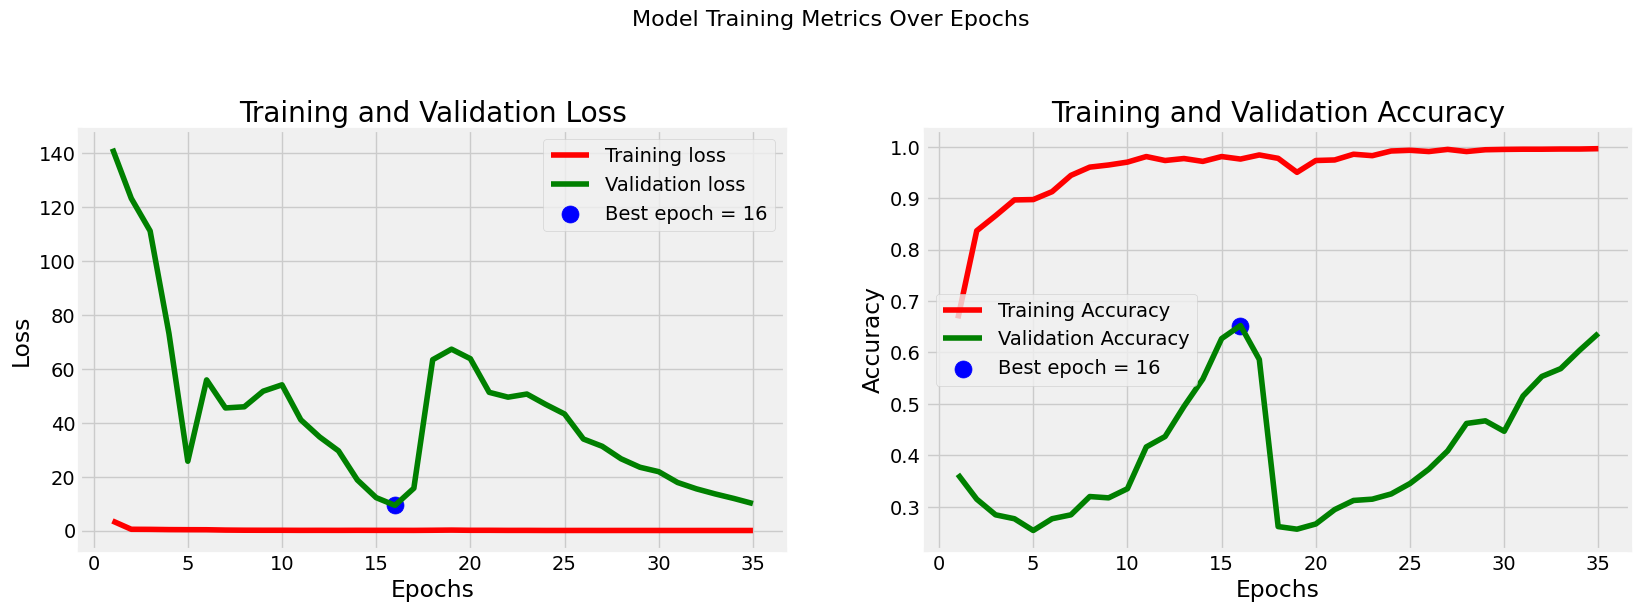

In [32]:
plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')

plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

In [34]:
MobileNet_model.save("mobilenet_model.keras")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Getting true labels and model predictions
y_true = []
y_pred = []

for images, labels in test_image_gen:
    preds = MobileNet_model.predict(images)   # Model predictions
    y_true.extend(np.argmax(labels, axis=1))  # True labels
    y_pred.extend(np.argmax(preds, axis=1))   # Predicted labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━

In [ ]:
# Computing confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Getting class names
class_names = list(test_image_gen.class_indices.keys())

# Visualizing confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Printing classification report
print(classification_report(y_true, y_pred, target_names=class_names))

<h1 id="final-model" style="color: #1B3A57;">Final Model & Prediction</h1>

In [ ]:
model.evaluate(test_image_gen)

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
pred_probabilities = model.predict(test_image_gen)
pred_probabilities

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(test_image_gen.classes,predictions))

In [ ]:
confusion_matrix(test_image_gen.classes,predictions)

In [ ]:
# Saving model
from tensorflow.keras.saving import save_model

save_model(model, 'malaria_cnn_model.keras')

<h1 id="conclusion" style="color: #1B3A57;">Conclusion</h1>

<p style="background-color:#1B3A57;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:60px 20px;"><b>THANK YOU!</b></p>